# Cohort quality control

This notebook reads what the pipeline recorded. It computes nothing of its own. Run `python data/download_data.py` and then `python analysis/run_all.py` before opening it.

The question the notebook answers is whether the images in the cohort can be pooled: what produced them, whether the pixel grid is stable, and whether the headers still identify anyone.

The stages it presents are `src/s02_headers.py`, which reads every DICOM header into one typed table, and `src/s03_qc.py`, which measures the equipment, the grid, the orientation, the encoding and the de-identification. Every figure below is shown under the function in `src/s08_figures.py` that drew it.

In [1]:
import inspect
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display

from src import config, s08_figures
from src.s99_utils import Metrics

pd.set_option("display.width", 110)
pd.set_option("display.max_rows", 60)

metrics = Metrics()


def table(name):
    return pd.read_csv(config.RESULTS / (name + ".csv"))


def source(obj):
    """One function of the pipeline, printed as it stands in src/.

    The source is printed and not returned as a rich display object, because a
    highlighted object carries a LaTeX and an HTML form of itself and a reader
    on the repository page is served whichever of the two that page prefers.
    Plain text renders the same everywhere.
    """
    print(inspect.getsource(obj).rstrip())


# Every figure is drawn by one function in src/s08_figures.py from a table in
# results/, so a figure and the prose beside it cannot disagree. Each figure is
# shown here under the function that drew it.
DRAWN_BY = {
    "fig01_scanner_inventory.png": s08_figures.fig_scanners,
    "fig02_series_descriptions.png": s08_figures.fig_series_types,
    "fig03_image_grids.png": s08_figures.fig_grids,
    "fig04_mask_alignment.png": s08_figures.fig_alignment,
    "fig05_patch_examples.png": s08_figures.fig_patches,
    "fig06_class_balance.png": s08_figures.fig_class_balance,
    "fig07_splits.png": s08_figures.fig_splits,
    "fig08_grid_search.png": s08_figures.fig_grid_search,
    "fig09_training_history.png": s08_figures.fig_history,
    "fig10_roc_test.png": s08_figures.fig_roc,
    "fig11_confusion_matrix.png": s08_figures.fig_confusion,
    "fig12_per_patient.png": s08_figures.fig_per_patient,
    "fig13_split_leakage.png": s08_figures.fig_leakage,
    "fig14_errors.png": s08_figures.fig_errors,
}


def figure(name):
    source(DRAWN_BY[name])
    display(Image(filename=str(config.FIGURES / name)))


## What the cohort contains

The manifest fixes which patients and which series were downloaded. Every series carries the same license.

In [2]:
manifest = pd.read_csv(config.MANIFEST)
print("patients", manifest["patient_id"].nunique())
print("series  ", len(manifest))
print("instances", int(manifest["instance_count"].sum()))
print("size, GB ", round(manifest["size_mb"].sum() / 1024, 2))
manifest.groupby("role")[["series_uid"]].count().rename(columns={"series_uid": "series"})

patients 49
series   322
instances 59762
size, GB  9.9


,series
role,
image,273
segmentation,49


## The rule the cohort was selected by

A patient enters the cohort when a segmentation with a reviewed segment sits on a series whose description carries a T1 marker and a post-contrast marker and carries no T2 or FLAIR marker. The rule reads tokens in the description and nothing else, so its boundary is a property of how each scanner named its protocols. `results/segmented_series_descriptions.csv` holds every description in the collection that carries a reviewed segmentation, with the rule's verdict on each, so what the rule excluded can be read beside what it admitted.


In [3]:
vocabulary = table("segmented_series_descriptions")
print("descriptions carrying a reviewed segmentation:",
      int(metrics.number("label_rule_vocabulary_descriptions")),
      "over", int(metrics.number("label_rule_vocabulary_rows")), "rows")
print("admitted by the rule:                       ",
      int(metrics.number("label_rule_admitted_descriptions")),
      "over", int(metrics.number("label_rule_admitted_rows")), "rows")
vocabulary[vocabulary["admitted"] == 1]


descriptions carrying a reviewed segmentation: 37 over 43 rows
admitted by the rule:                        8 over 9 rows


,series_desc,manufacturer,model_name,patients,series,admitted
2,AX T1 POST: Processed_CaPTk,SIEMENS,Avanto,2,2,1
9,POST AX T1 FS FSE: Processed_CaPTk,GE MEDICAL SYSTEMS,DISCOVERY MR750w,1,1,1
12,AX T1 POST STEALTH: Processed_CaPTk,SIEMENS,Espree,2,2,1
15,AXIAL T1 FLOW COMP POST : Processed_CaPTk,SIEMENS,SymphonyTim,1,1,1
19,AX T1 3D POST STEALTH : Processed_CaPTk,SIEMENS,TrioTim,1,1,1
28,t1 axial stealth-post : Processed_CaPTk,SIEMENS,TrioTim,30,30,1
29,t1 axial stealth-post_T : Processed_CaPTk,SIEMENS,TrioTim,7,7,1
30,t1 axial stealth-post_TERA: Processed_CaPTk,SIEMENS,TrioTim,4,4,1
39,AX T1 3D POST STEALTH : Processed_CaPTk,SIEMENS,Verio,1,1,1


The rejected rows carry both the rule's intent and its limit. `Ax T2 POST` is a post-contrast acquisition and is excluded for being T2, which is the rule doing what it claims. The rows below are T1 acquisitions whose descriptions name no contrast state at all: the rule cannot see which side of the injection they were acquired on, so it excludes them whichever side that was.


In [4]:
lower = vocabulary["series_desc"].str.lower()


def carries(markers):
    return lower.map(lambda text: any(m in text for m in markers))


unnamed = vocabulary[(vocabulary["admitted"] == 0)
                     & carries(["t1"])
                     & ~carries(config.LABEL_EXCLUDED_MARKERS)
                     & ~carries(config.CONTRAST_STATE_MARKERS)]
print("T1 series naming no contrast state:", len(unnamed), "rows over",
      unnamed["series_desc"].nunique(), "descriptions")
unnamed


T1 series naming no contrast state: 11 rows over 10 descriptions


,series_desc,manufacturer,model_name,patients,series,admitted
1,AX T1 MPRAGE ISOTROPIC: Processed_CaPTk,SIEMENS,Avanto,2,2,0
7,AX T1 FSE : Processed_CaPTk,GE MEDICAL SYSTEMS,DISCOVERY MR750w,1,1,0
11,AX T1 MPRAGE ISOTROPIC: Processed_CaPTk,SIEMENS,Espree,1,1,0
17,T1 AXIAL SE : Processed_CaPTk,SIEMENS,SymphonyTim,1,1,0
22,AXIAL T1 BRAIN 3D : Processed_CaPTk,SIEMENS,TrioTim,1,1,0
23,AXIAL T1 MPRAGE BRAIN : Processed_CaPTk,SIEMENS,TrioTim,3,5,0
31,t1 axial: Processed_CaPTk,SIEMENS,TrioTim,30,30,0
32,t1 axial_ 3D_T: Processed_CaPTk,SIEMENS,TrioTim,1,1,0
33,t1 axial_ 3D_TERA : Processed_CaPTk,SIEMENS,TrioTim,2,2,0
34,t1 axial_T: Processed_CaPTk,SIEMENS,TrioTim,6,6,0


## Acquisition equipment

Signal intensity in magnetic resonance depends on the scanner and the sequence, so the equipment present bounds what a model trained on the cohort can be expected to transfer to.

In [5]:
table("scanner_inventory")

,manufacturer,model_name,series,patients
0,SIEMENS,TrioTim,239,42
1,SIEMENS,Espree,12,3
2,SIEMENS,Avanto,8,2
3,SIEMENS,Verio,6,1
4,GE MEDICAL SYSTEMS,DISCOVERY MR750w,4,1
5,SIEMENS,SymphonyTim,4,1


def fig_scanners():
    rows = table("scanner_inventory")
    labels = [r["manufacturer"] + "\n" + r["model_name"] for r in rows]
    counts = [int(r["series"]) for r in rows]
    patients = [int(r["patients"]) for r in rows]
    figure, axis = plt.subplots(figsize=(7, 3.4))
    positions = np.arange(len(labels))
    axis.bar(positions - 0.2, counts, 0.4, label="series", color=BLUE)
    axis.bar(positions + 0.2, patients, 0.4, label="patients", color=ORANGE)
    axis.set_xticks(positions)
    axis.set_xticklabels(labels, fontsize=7)
    axis.set_ylabel("count")
    axis.set_title("Acquisition equipment in the cohort")
    axis.legend(frameon=False)
    return save(figure, "fig01_scanner_inventory.png")


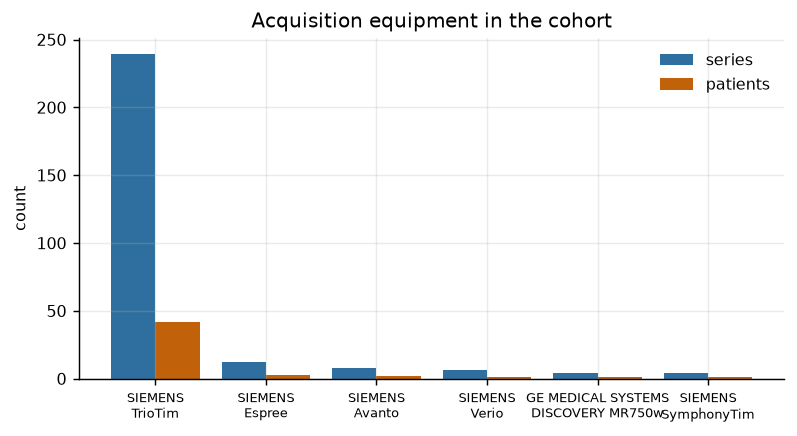

In [6]:
figure("fig01_scanner_inventory.png")

## Series types

The studies hold diffusion and perfusion acquisitions alongside the structural series. They are counted here and excluded from the labeled task, because their contrast is not the contrast the segmentation was drawn on.

In [7]:
inventory = table("series_inventory")
inventory["series_desc"].value_counts().head(20).to_frame("series")

,series
series_desc,
Axial T2 tse: Processed_CaPTk,33
t2_Flair_axial: Processed_CaPTk,30
t1 axial: Processed_CaPTk,30
t1 axial stealth-post : Processed_CaPTk,30
ep2d_DTI_30dir,25
ep2d_perf BOLUS,12
ep2d_perf 12 CC BOLUS,10
T2 SAG SPACE: Processed_CaPTk,8
t2_Flair_axial_T: Processed_CaPTk,7


def fig_series_types():
    rows = table("series_inventory")
    counts = {}
    for row in rows:
        counts[row["series_desc"]] = counts.get(row["series_desc"], 0) + 1
    order = sorted(counts.items(), key=lambda kv: kv[1])
    figure, axis = plt.subplots(figsize=(7, 0.22 * len(order) + 1.2))
    axis.barh([k for k, _ in order], [v for _, v in order], color=BLUE)
    axis.set_xlabel("series")
    axis.set_title("Series descriptions present in the cohort")
    axis.tick_params(axis="y", labelsize=6)
    return save(figure, "fig02_series_descriptions.png")


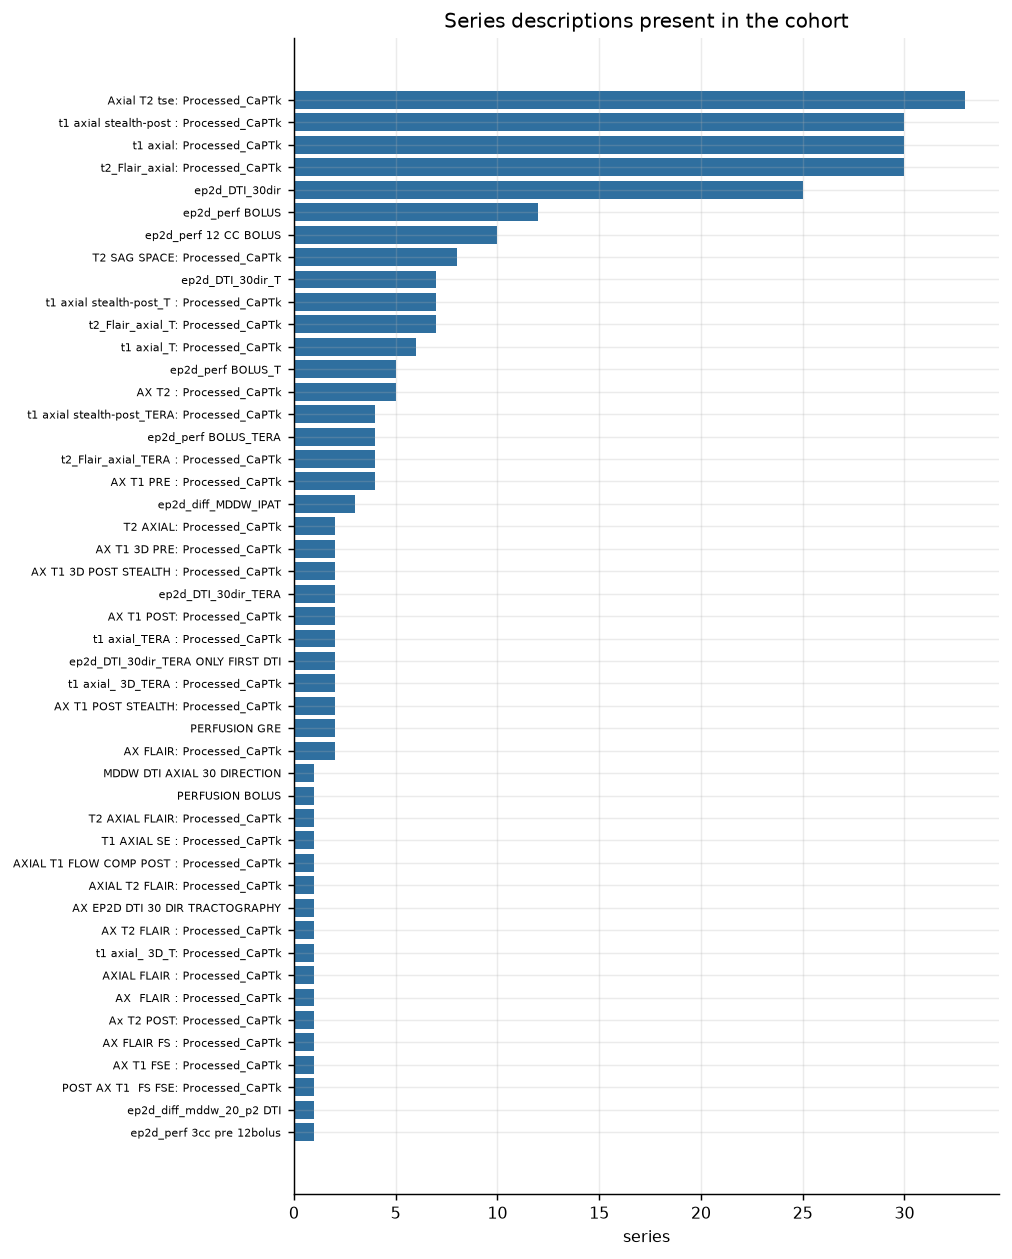

In [8]:
figure("fig02_series_descriptions.png")

## Image grid stability

A patient whose first and last series differ in row or column count cannot be stacked into one array without resampling.

In [9]:
findings = table("qc_findings")
print("patients whose first and last series differ in size:",
      int(metrics.number("qc_patients_with_dimension_change")))
print("patients holding more than one grid:",
      int(metrics.number("qc_patients_with_multiple_grids")))
findings[(findings["check"] == "first_last_dimensions") & (findings["flagged"] == 1)]

patients whose first and last series differ in size: 34
patients holding more than one grid: 48


,check,subject,detail,flagged
10,first_last_dimensions,UPENN-GBM-00020,896x896 then 256x192,1
12,first_last_dimensions,UPENN-GBM-00048,896x896 then 128x128,1
13,first_last_dimensions,UPENN-GBM-00049,256x192 then 896x896,1
14,first_last_dimensions,UPENN-GBM-00050,128x128 then 256x192,1
15,first_last_dimensions,UPENN-GBM-00062,128x128 then 896x896,1
17,first_last_dimensions,UPENN-GBM-00085,128x128 then 896x896,1
19,first_last_dimensions,UPENN-GBM-00142,256x192 then 256x208,1
22,first_last_dimensions,UPENN-GBM-00224,128x128 then 256x192,1
23,first_last_dimensions,UPENN-GBM-00226,320x256 then 256x192,1
24,first_last_dimensions,UPENN-GBM-00231,128x128 then 256x192,1


def fig_grids():
    rows = table("series_inventory")
    grids = {}
    for row in rows:
        key = (int(row["rows_px"]), int(row["cols_px"]))
        grids[key] = grids.get(key, 0) + 1
    per_patient = {}
    for row in rows:
        per_patient.setdefault(row["patient_id"], set()).add(
            (int(row["rows_px"]), int(row["cols_px"])))
    distinct = sorted(len(v) for v in per_patient.values())

    figure, axes = plt.subplots(1, 2, figsize=(8, 3.2))
    labels = ["{}x{}".format(*k) for k in sorted(grids)]
    axes[0].bar(labels, [grids[k] for k in sorted(grids)], color=BLUE)
    axes[0].set_ylabel("series")
    axes[0].set_title("Image grids across the cohort")
    axes[0].tick_params(axis="x", rotation=45, labelsize=7)
    values, counts = np.unique(distinct, return_counts=True)
    axes[1].bar(values, counts, color=ORANGE)
    axes[1].set_xlabel("distinct grids held by one patient")
    axes[1].set_ylabel("patients")
    axes[1].set_xticks(values)
    axes[1].set_title("

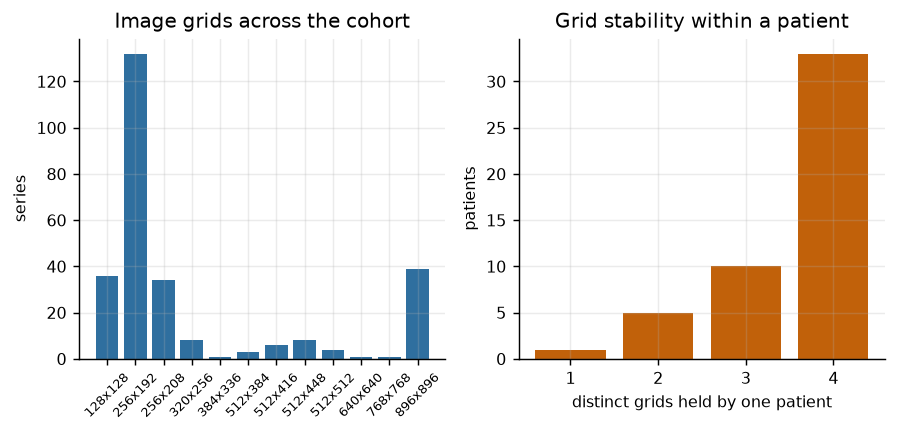

In [10]:
figure("fig03_image_grids.png")

## Pixel encoding

Photometric interpretation decides whether a high stored value is bright or dark. A cohort mixing the two would train a model on inverted images without any error being raised.

In [11]:
findings[findings["check"].isin(["photometric_interpretation",
                                 "bits_allocated", "modality",
                                 "within_series_constant"])]

,check,subject,detail,flagged
8,modality,MR,273 series,0
107,photometric_interpretation,MONOCHROME2,273 series,0
108,bits_allocated,16,273 series,0
124,within_series_constant,bits_allocated,0 series carry more than one value,0
125,within_series_constant,cols,0 series carry more than one value,0
126,within_series_constant,manufacturer,0 series carry more than one value,0
127,within_series_constant,model_name,0 series carry more than one value,0
128,within_series_constant,photometric_interpretation,0 series carry more than one value,0
129,within_series_constant,rows,0 series carry more than one value,0


## De-identification

One instance from every series is checked against the tags that carry identity. Anything populated here would be a reason to stop.

The burned-in annotation count is reported three ways. The tag is absent from all 322 audited series, so a single zero beside it would read as a tag that was populated and read negative. Establishing that no image carries burned-in text would take a reading of the pixel data, which this audit does not perform.


In [12]:
audit = table("phi_audit")
summary = {
    "series audited": len(audit),
    "identifier tags populated": int(
        metrics.number("phi_series_with_populated_identifier_tags")),
    "burned-in annotation declared YES": int(
        metrics.number("phi_burned_in_annotation_yes")),
    "burned-in annotation declared NO": int(
        metrics.number("phi_burned_in_annotation_no")),
    "series not carrying the burned-in tag": int(
        metrics.number("phi_burned_in_annotation_absent")),
    "patient identifiers off the collection form": int(
        metrics.number("phi_patient_id_non_conforming")),
    "series carrying private tags": int(
        metrics.number("phi_series_with_private_tags")),
    "largest private tag count": int(metrics.number("phi_max_private_tags")),
}
pd.Series(summary).to_frame("count")


,count
series audited,322
identifier tags populated,0
burned-in annotation declared YES,0
burned-in annotation declared NO,0
series not carrying the burned-in tag,322
patient identifiers off the collection form,0
series carrying private tags,273
largest private tag count,43


## The label and the image share a coordinate system

The segmentation is stored on its own grid, whose in-plane orientation is the negative of the image orientation. Resampling through the patient coordinate system puts the two on one grid, and the overlay is the check that it worked.

def fig_alignment():
    """One slice with its resampled mask, the check that the label lines up."""
    patient_id, image_row, seg_row = labeled_pairs()[0]
    volume = load_volume(patient_id, image_row)
    # load_mask returns the mask, the per-segment voxel counts and the
    # provenance of the label; only the mask is drawn here.
    mask, _, _ = load_mask(patient_id, seg_row, volume)
    image = volume.array.astype(np.float32)
    image = image / max(float(np.percentile(image[image > 0], 99.5)), 1e-6)
    per_slice = mask.reshape(len(image), -1).sum(1)
    z = int(per_slice.argmax())

    figure, axes = plt.subplots(1, 3, figsize=(8.4, 3.2))
    axes[0].imshow(np.clip(image[z], 0, 1), cmap="gray")
    axes[0].set_title("T1 post-contrast, slice {}".format(z))
    axes[1].imshow(mask[z], cmap="gray")
    axes[1].set_title("whole-tumor mask")
    axes[2].imshow(np.clip(image[z], 0, 1), cmap="gray")
    axes[2].imshow(np.ma.masked_where(~mask[z], mask[z]), cmap="autumn", alpha=0.45)
 

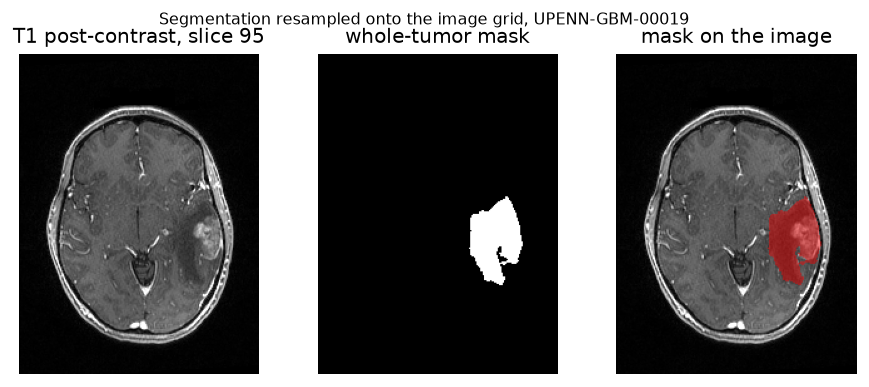

In [13]:
figure("fig04_mask_alignment.png")

## The record these results were read from

Every number and every figure above was read from `results/` and `figures/` as the pipeline last wrote them. The signature below is a digest of the recorded quantities that a re-run reproduces exactly. Gate 07 recomputes it from `results/metrics.csv` and compares, so a notebook left standing against an older record fails a gate instead of going on being read.


In [14]:
from src.s99_utils import record_signature

# One string in one call, so the label and the digest cannot be split
# across two stream messages by the kernel.
print("{} {}".format(config.RECORD_SIGNATURE_LABEL, record_signature()))


record signature 57545bc7f42d7587
